# **Conectividade em grafos**

Francisco A. Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
<hr>

Neste notebook, vamos estudar as principais medidas estatísticas associadas ao **grau dos nós** em uma rede complexa, isto é, ao número de conexões de cada vértice. Embora o grau seja uma das medidas locais mais simples de uma rede, a partir de sua distribuição podemos construir diversos indicadores, desde momentos estatísticos até índices inspirados na bibliometria, como o **h-index**, e na economia, como o **coeficiente de Gini**, que permitem caracterizar a heterogeneidade e compreender aspectos importantes da organização estrutural da rede.

Como estudo de caso, vamos analisar a **rede de ruas de São Carlos, SP**, obtida por meio da biblioteca [`OSMnx`](https://osmnx.readthedocs.io/), que permite construir grafos a partir dos dados do OpenStreetMap. Nessa representação, cada nó corresponde, em geral, a uma interseção ou extremidade de rua, enquanto cada aresta representa um trecho de via conectando dois nós. Assim, o grau de um nó indica quantos trechos de rua estão conectados àquela interseção, fornecendo uma medida simples da conectividade local da malha urbana.

**Roteiro do notebook:**

1. Configuração do ambiente e download da rede
2. Sequência e distribuição de grau
3. Grau médio
4. Momentos do grau (2º e 3º)
5. Variância e desvio padrão
6. Coeficiente de variação
7. Entropia do grau
8. Grau máximo e mínimo
9. Quantis e intervalo interquartil
10. Boxplot do grau
11. Grau médio dos vizinhos (k_nn) e assortatividade
12. Índice h dos graus
13. Coeficiente de Gini dos graus
14. Tabela-resumo e discussão
15. Exercícios propostos

### 1. Configuração do ambiente

Vamos importar as bibliotecas necessárias. Assumimos que o `OSMnx` já está instalado no ambiente (`pip install osmnx`).

- `osmnx`: download e manipulação de redes viárias do OpenStreetMap
- `networkx`: estrutura de grafo e algoritmos de rede
- `numpy` / `scipy`: cálculos numéricos e estatísticos
- `matplotlib`: visualizações


In [2]:
%pip install scipy
%pip install osmnx
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configurações visuais
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.3

ox.settings.log_console = False
ox.settings.use_cache = True

np.random.seed(42)
print("Bibliotecas carregadas. Versão do OSMnx:", ox.__version__)

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --- ------------------------------------ 3.4/36.6 MB 20.4 MB/s eta 0:00:02
   -------- ------------------------------- 7.6/36.6 MB 20.7 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/36.6 MB 21.4 MB/s eta 0:00:02
   ------------------ --------------------- 17.0/36.6 MB 21.6 MB/s eta 0:00:01
   ------------------------ --------------- 22.3/36.6 MB 22.1 MB/s eta 0:00:01
   ----------------------------- ---------- 27.3/36.6 MB 22.3 MB/s eta 0:00:01
   ----------------------------------- ---- 32.2/36.6 MB 22.7 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 22.6 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 22.6 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 17.9 MB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\paulo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\paulo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Bibliotecas carregadas. Versão do OSMnx: 2.1.1


### 2. Download da rede viária: São Carlos (SP)

Vamos baixar a rede de ruas de **São Carlos, SP, Brasil**, utilizando o tipo `drive` (ruas para veículos). O grafo retornado pelo OSMnx é um `MultiDiGraph` (multigrafo direcionado, pois ruas podem ter mão única e existir mais de uma via entre dois mesmos cruzamentos).

Para o estudo de **grau** costuma-se trabalhar com a versão **não-direcionada e simplificada** da rede, pois:

- Em uma rua de mão dupla, tratar o par de arestas (ida e volta) como uma única conexão física é mais fiel à ideia de "quantas ruas se encontram neste cruzamento".
- Multi-arestas paralelas entre o mesmo par de nós (por exemplo, uma rotatória modelada com dois arcos) podem inflar artificialmente o grau se não forem simplificadas.


In [3]:
lugar = "São Carlos, São Paulo, Brasil"

# Baixa a rede viária (tipo 'drive': ruas para carros)
G_osm = ox.graph_from_place(lugar, network_type="drive")

print(f"Rede baixada para: {lugar}")
print(f"Nº de nós (bruto, direcionado): {G_osm.number_of_nodes()}")
print(f"Nº de arestas (bruto, direcionado): {G_osm.number_of_edges()}")

Rede baixada para: São Carlos, São Paulo, Brasil
Nº de nós (bruto, direcionado): 9217
Nº de arestas (bruto, direcionado): 22638


In [4]:
# Convertemos para grafo simples não-direcionado
G_undirected = ox.convert.to_undirected(G_osm)
G = nx.Graph(G_undirected)   # remove multi-arestas paralelas
G.remove_edges_from(nx.selfloop_edges(G))  # remove laços (self-loops), se existirem

N = G.number_of_nodes()
E = G.number_of_edges()
print(f"Rede simplificada (não-direcionada, simples):")
print(f"  Nós (cruzamentos): {N}")
print(f"  Arestas (trechos de rua): {E}")
print(f"  Grau médio teórico (2E/N): {2*E/N:.3f}")

Rede simplificada (não-direcionada, simples):
  Nós (cruzamentos): 9217
  Arestas (trechos de rua): 13881
  Grau médio teórico (2E/N): 3.012


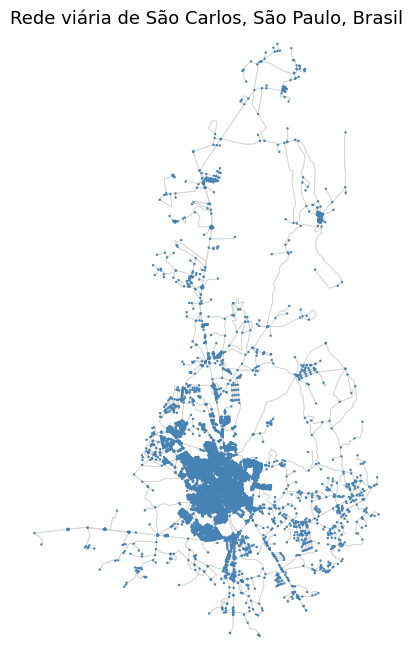

In [5]:
# Visualização geral da rede
fig, ax = ox.plot_graph(
    G_osm, node_size=3, node_color="steelblue", edge_color="lightgray",
    edge_linewidth=0.5, bgcolor="white", show=False, close=False
)
ax.set_title(f"Rede viária de {lugar}", fontsize=13)
plt.show()

### 3. Sequência e distribuição de grau

O **grau** de um nó $i$, denotado $k_i$, é o número de arestas incidentes a ele. No nosso caso, o número de trechos de rua que partem de um cruzamento.

A **sequência de graus** é o conjunto $\{k_1, k_2, \dots, k_N\}$ com um valor por nó.

A **distribuição de grau** $P(k)$ é a probabilidade de um nó escolhido ao acaso ter grau exatamente igual a $k$:

$$P(k) = \frac{n_k}{N}$$

em que $n_k$ é o número de nós com grau $k$ e $N$ é o número total de nós. Em redes viárias, é comum que $P(k)$ seja fortemente concentrada em poucos valores (3 e 4, tipicamente), pois cruzamentos costumam ter poucas ruas se encontrando, diferente de redes livres de escala como a internet, onde $P(k)$ tem cauda longa.

In [6]:
# ------------------------------------------------------------
# Sequência de graus da rede
# ------------------------------------------------------------

# G.degree() retorna pares da forma:
# (nó, grau)
# Exemplo:
# (0, 3)  -> o vértice 0 possui grau 3
# (1, 5)  -> o vértice 1 possui grau 5

# Extraímos apenas o grau de cada nó.
graus = np.array([grau for vertice, grau in G.degree()])

# Mostramos os graus dos primeiros 10 nós.
print("Graus dos primeiros 10 nós:")
print(graus[:10])

# Como existe um valor de grau para cada nó,
# o tamanho desse vetor corresponde ao número de nós da rede.
print(f"\nNúmero total de nós da rede: {len(graus)}")

Graus dos primeiros 10 nós:
[3 3 3 3 3 3 4 3 4 4]

Número total de nós da rede: 9217


In [7]:
# Distribuição de grau (PMF empírica)
valores_k, contagens = np.unique(graus, return_counts=True)
P_k = contagens / contagens.sum()

tabela_dist = pd.DataFrame({"grau (k)": valores_k, "n_k (contagem)": contagens, "P(k)": P_k})
tabela_dist

,grau (k),n_k (contagem),P(k)
0,1,955,0.103613
1,2,196,0.021265
2,3,5860,0.635782
3,4,2196,0.238255
4,5,9,0.000976
5,6,1,0.000108


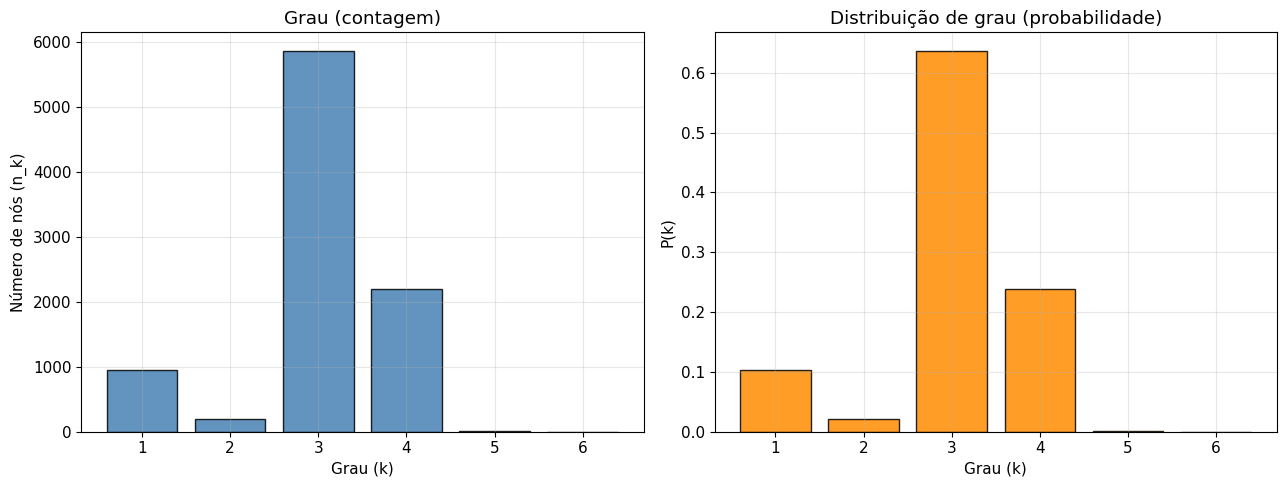

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma da sequência de graus
axes[0].bar(valores_k, contagens, color="steelblue", edgecolor="black", alpha=0.85)
axes[0].set_xlabel("Grau (k)")
axes[0].set_ylabel("Número de nós (n_k)")
axes[0].set_title("Grau (contagem)")

# PMF normalizada
axes[1].bar(valores_k, P_k, color="darkorange", edgecolor="black", alpha=0.85)
axes[1].set_xlabel("Grau (k)")
axes[1].set_ylabel("P(k)")
axes[1].set_title("Distribuição de grau (probabilidade)")

plt.tight_layout()
plt.show()

Em redes viárias reais, a distribuição de grau costuma ser bem diferente da observada em redes sociais ou na web. Como ruas obedecem a restrições físicas de planejamento urbano, a maior parte dos cruzamentos tem grau 3 ou 4 (um cruzamento em "T" ou uma interseção comum de duas ruas), sendo raros os nós de grau muito alto, ao contrário do que ocorre em redes livres de escala.

### 4. Grau médio

O **grau médio** $\langle k \rangle$ é o primeiro momento da distribuição de grau:

$$\langle k \rangle = \frac{1}{N}\sum_{i=1}^{N} k_i = \sum_k k \, P(k)$$

Para um grafo simples não-direcionado, existe ainda uma relação exata com o número de arestas $E$:

$$\langle k \rangle = \frac{2E}{N}$$

pois cada aresta contribui com $+1$ para o grau de **dois** nós.


In [9]:
grau_medio = graus.mean()
grau_medio_formula = 2 * E / N

print(f"Grau médio <k> (via média direta): {grau_medio:.4f}")
print(f"Grau médio <k> (via 2E/N):          {grau_medio_formula:.4f}")
print(f"As duas contas coincidem: {np.isclose(grau_medio, grau_medio_formula)}")

Grau médio <k> (via média direta): 3.0120
Grau médio <k> (via 2E/N):          3.0120
As duas contas coincidem: True


### 5. Segundo e terceiro momentos do grau

Os **momentos estatísticos** generalizam a ideia de grau médio. O momento de ordem $n$ é definido como:

$$\langle k^n \rangle = \frac{1}{N}\sum_{i=1}^N k_i^n = \sum_k k^n P(k)$$

- O **segundo momento** $\langle k^2 \rangle$ mede a dispersão dos graus ao redor de zero, sendo usado no cálculo da variância.
- O **terceiro momento** $\langle k^3 \rangle$ captura a **assimetria (skewness)** da distribuição: distribuições com cauda longa à direita (poucos nós com grau muito alto, os "hubs") têm $\langle k^3 \rangle$ desproporcionalmente grande.

In [10]:
m1 = np.mean(graus)
m2 = np.mean(graus**2)
m3 = np.mean(graus**3)

print(f"<k>   (1º momento): {m1:.4f}")
print(f"<k^2> (2º momento): {m2:.4f}")
print(f"<k^3> (3º momento): {m3:.4f}")

<k>   (1º momento): 3.0120
<k^2> (2º momento): 9.7511
<k^3> (3º momento): 32.8337


### 6. Variância e desvio padrão do grau

A **variância do grau** mede o quanto os graus se dispersam em torno da média:

$$\sigma_k^2 = \langle k^2 \rangle - \langle k \rangle^2 = \frac{1}{N}\sum_{i=1}^N (k_i - \langle k \rangle)^2$$

O **desvio padrão** é $\sigma_k = \sqrt{\sigma_k^2}$, na mesma unidade do grau (mais interpretável que a variância).

Quanto maior $\sigma_k$, mais **heterogênea** é a rede em termos de conectividade local.


In [11]:
var_k = np.var(graus)                    # equivalente a m2 - m1**2
var_k_formula = m2 - m1**2
std_k = np.std(graus)

print(f"Variância do grau (np.var):       {var_k:.4f}")
print(f"Variância do grau (<k^2> - <k>^2): {var_k_formula:.4f}")
print(f"Desvio padrão do grau:             {std_k:.4f}")

Variância do grau (np.var):       0.6787
Variância do grau (<k^2> - <k>^2): 0.6787
Desvio padrão do grau:             0.8238


### 7. Coeficiente de variação

O **coeficiente de variação (CV)** normaliza o desvio padrão pela média, permitindo comparar a dispersão de redes com escalas de grau diferentes:

$$CV = \frac{\sigma_k}{\langle k \rangle}$$

Valores de $CV$ próximos de zero indicam uma rede bastante **homogênea** (todos os nós com grau parecido); valores altos indicam forte heterogeneidade, que é comum em redes com hubs.


In [12]:
cv_k = std_k / grau_medio
print(f"Coeficiente de variação do grau: {cv_k:.4f}")

if cv_k < 0.3:
    interpretacao = "rede bastante homogênea em termos de grau"
elif cv_k < 0.7:
    interpretacao = "heterogeneidade moderada"
else:
    interpretacao = "rede fortemente heterogênea (possíveis hubs)"

print(f"Interpretação: {interpretacao}")

Coeficiente de variação do grau: 0.2735
Interpretação: rede bastante homogênea em termos de grau


### 8. Entropia do grau

A **entropia de Shannon** aplicada à distribuição de grau mede o grau de "incerteza" ou "diversidade" da distribuição $P(k)$:

$$H(K) = -\sum_k P(k)\, \log_2 P(k)$$

- $H$ é **máxima** quando os graus estão uniformemente distribuídos entre todos os valores possíveis (máxima incerteza sobre o grau de um nó sorteado ao acaso).
- $H$ é **mínima** ($H=0$) quando todos os nós têm exatamente o mesmo grau (rede regular).

Costuma-se também reportar a **entropia normalizada** $H/\log_2(k_{max}-k_{min}+1)$, que varia entre 0 e 1, facilitando comparações entre redes.


In [13]:
H = -np.sum(P_k * np.log2(P_k))

n_valores_possiveis = graus.max() - graus.min() + 1
H_max = np.log2(n_valores_possiveis)
H_norm = H / H_max

print(f"Entropia do grau H(K):            {H:.4f} bits")
print(f"Entropia máxima possível:         {H_max:.4f} bits")
print(f"Entropia normalizada (0 a 1):      {H_norm:.4f}")

Entropia do grau H(K):            1.3767 bits
Entropia máxima possível:         2.5850 bits
Entropia normalizada (0 a 1):      0.5326


### 9. Grau máximo e mínimo

Medidas simples, mas informativas sobre os extremos da rede:

- $k_{max}$: grau do nó mais conectado (o "hub" local da rede, se existir)
- $k_{min}$: grau do nó menos conectado

Em uma rede viária conexa e sem nós desconectados, espera-se $k_{min} \geq 1$.


In [14]:
k_max = graus.max()
k_min = graus.min()

nos_k_max = [n for n, k in G.degree() if k == k_max]
nos_k_min = [n for n, k in G.degree() if k == k_min]

print(f"Grau máximo k_max: {k_max}  (nº de nós com esse grau: {len(nos_k_max)})")
print(f"Grau mínimo k_min: {k_min}  (nº de nós com esse grau: {len(nos_k_min)})")

Grau máximo k_max: 6  (nº de nós com esse grau: 1)
Grau mínimo k_min: 1  (nº de nós com esse grau: 955)


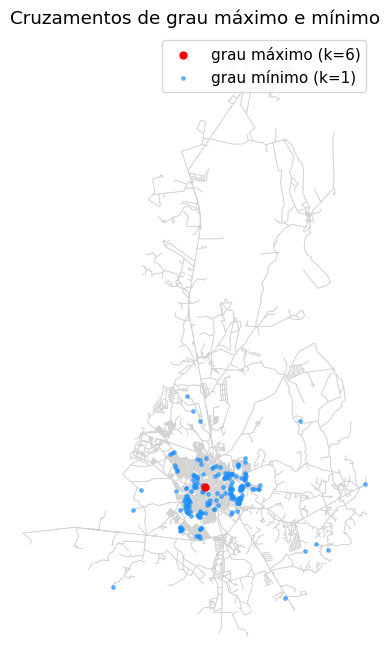

In [15]:
# Visualizando espacialmente os cruzamentos de grau máximo e mínimo
fig, ax = ox.plot_graph(
    G_osm, node_size=0, edge_color="lightgray", edge_linewidth=0.5,
    bgcolor="white", show=False, close=False
)

xs_max = [G.nodes[n]['x'] for n in nos_k_max]
ys_max = [G.nodes[n]['y'] for n in nos_k_max]
xs_min = [G.nodes[n]['x'] for n in nos_k_min[:200]]  # limita p/ não poluir o plot
ys_min = [G.nodes[n]['y'] for n in nos_k_min[:200]]

ax.scatter(xs_max, ys_max, c="red", s=25, label=f"grau máximo (k={k_max})", zorder=5)
ax.scatter(xs_min, ys_min, c="dodgerblue", s=6, alpha=0.6, label=f"grau mínimo (k={k_min})", zorder=4)
ax.legend(loc="upper right")
ax.set_title("Cruzamentos de grau máximo e mínimo")
plt.show()

### 10. Quantis e intervalo interquartil (IQR)

Os **quantis** dividem a distribuição de grau em partes com a mesma proporção de observações. Os mais usados são os **quartis**:

- $Q_1$ (25º percentil): 25% dos nós têm grau $\leq Q_1$
- $Q_2$ (mediana, 50º percentil)
- $Q_3$ (75º percentil): 75% dos nós têm grau $\leq Q_3$

O **intervalo interquartil (IQR)** é uma medida robusta de dispersão (pouco sensível a outliers):

$$IQR = Q_3 - Q_1$$


In [16]:
q1, q2, q3 = np.percentile(graus, [25, 50, 75])
iqr = q3 - q1

# limites de outlier (regra de Tukey)
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
outliers = graus[(graus < lim_inf) | (graus > lim_sup)]

print(f"Q1 (25%):  {q1:.2f}")
print(f"Q2 (mediana): {q2:.2f}")
print(f"Q3 (75%):  {q3:.2f}")
print(f"IQR:       {iqr:.2f}")
print(f"Limites de outlier (Tukey): [{lim_inf:.2f}, {lim_sup:.2f}]")
print(f"Nº de nós outliers pelo critério de Tukey: {len(outliers)} ({100*len(outliers)/N:.2f}% da rede)")

Q1 (25%):  3.00
Q2 (mediana): 3.00
Q3 (75%):  3.00
IQR:       0.00
Limites de outlier (Tukey): [3.00, 3.00]
Nº de nós outliers pelo critério de Tukey: 3357 (36.42% da rede)


### 11. Boxplot do grau

O **boxplot** (diagrama de caixa) resume visualmente mediana, quartis, IQR e outliers em uma única figura — é a contrapartida gráfica direta da seção anterior.


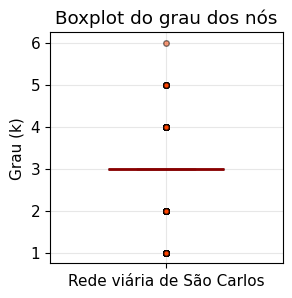

In [17]:
fig, ax = plt.subplots(figsize=(3, 3))
bp = ax.boxplot(graus, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor="lightsteelblue"),
                medianprops=dict(color="darkred", linewidth=2),
                flierprops=dict(marker="o", markerfacecolor="orangered",
                                 markersize=4, alpha=0.5))
ax.set_ylabel("Grau (k)")
ax.set_title("Boxplot do grau dos nós")
ax.set_xticklabels(["Rede viária de São Carlos"])
plt.show()

### 12. Grau médio dos vizinhos e assortatividade

O **grau médio dos vizinhos** de um nó $i$, $k_{nn,i}$, mede a conectividade média de quem está diretamente ligado a $i$:

$$k_{nn,i} = \frac{1}{k_i}\sum_{j \in \mathcal{N}(i)} k_j$$

em que $\mathcal{N}(i)$ é o conjunto de vizinhos de $i$. Essa medida é a base para investigar **correlações de grau** (assortatividade):

- Se nós de grau alto tendem a se conectar com outros nós de grau alto → rede **assortativa** ($k_{nn}(k)$ crescente com $k$).
- Se nós de grau alto tendem a se conectar com nós de grau baixo → rede **dissortativa** ($k_{nn}(k)$ decrescente).

O **coeficiente de assortatividade de grau** resume essa tendência em um único número, entre $-1$ e $1$ (correlação de Pearson entre os graus nas duas extremidades de cada aresta).


In [18]:
knn_dict = nx.average_neighbor_degree(G)
knn_vals = np.array(list(knn_dict.values()))

knn_medio_geral = knn_vals.mean()
print(f"Grau médio dos vizinhos, em média sobre toda a rede: {knn_medio_geral:.4f}")
print(f"Grau médio da rede <k>:                              {grau_medio:.4f}")

Grau médio dos vizinhos, em média sobre toda a rede: 3.2031
Grau médio da rede <k>:                              3.0120


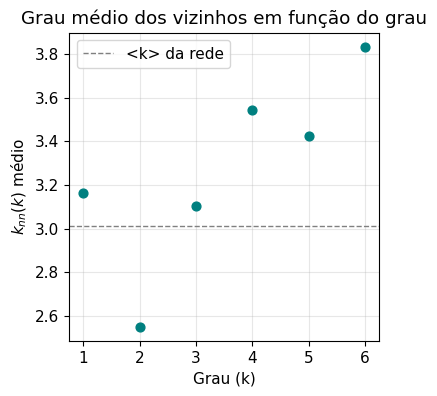

Coeficiente de assortatividade de grau (Newman): 0.2664
→ Rede levemente/fortemente assortativa: nós de grau parecido tendem a se conectar.


In [19]:
# k_nn(k): grau médio dos vizinhos, agregado por classe de grau k
df_knn = pd.DataFrame({"grau": graus, "knn": knn_vals})
knn_por_grau = df_knn.groupby("grau")["knn"].mean()

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(knn_por_grau.index, knn_por_grau.values, color="teal", s=40, zorder=3)
ax.axhline(grau_medio, color="gray", linestyle="--", linewidth=1, label="<k> da rede")
ax.set_xlabel("Grau (k)")
ax.set_ylabel(r"$k_{nn}(k)$ médio")
ax.set_title("Grau médio dos vizinhos em função do grau")
ax.legend()
plt.show()

assortatividade = nx.degree_assortativity_coefficient(G)
print(f"Coeficiente de assortatividade de grau (Newman): {assortatividade:.4f}")
if assortatividade > 0.05:
    print("→ Rede levemente/fortemente assortativa: nós de grau parecido tendem a se conectar.")
elif assortatividade < -0.05:
    print("→ Rede dissortativa: nós de grau alto tendem a se ligar a nós de grau baixo.")
else:
    print("→ Correlação de grau próxima de neutra.")

### 13. Índice h dos graus

O **índice h**, popularizado por Hirsch para medir produtividade científica, pode ser aplicado à sequência de graus de uma rede. Definição:

> O índice $h$ é o maior número tal que existam pelo menos $h$ nós com grau $\geq h$.

Formalmente, ordenando os graus em ordem decrescente $k_{(1)} \geq k_{(2)} \geq \dots \geq k_{(N)}$:

$$h = \max\{\, i : k_{(i)} \geq i \,\}$$

O índice h combina, em um único número, informação sobre **quantidade** de nós bem conectados e **magnitude** dos seus graus. É mais robusto a outliers extremos do que $k_{max}$ isoladamente.


In [20]:
def indice_h(sequencia_graus):
    graus_ordenados = sorted(sequencia_graus, reverse=True)
    h = 0
    for posicao, k in enumerate(graus_ordenados, start=1):
        if k >= posicao:
            h = posicao
        else:
            break
    return h

h = indice_h(graus)
print(f"Índice h da rede: h = {h}")
print(f"Interpretação: existem pelo menos {h} nós com grau maior ou igual a {h}.")

Índice h da rede: h = 5
Interpretação: existem pelo menos 5 nós com grau maior ou igual a 5.


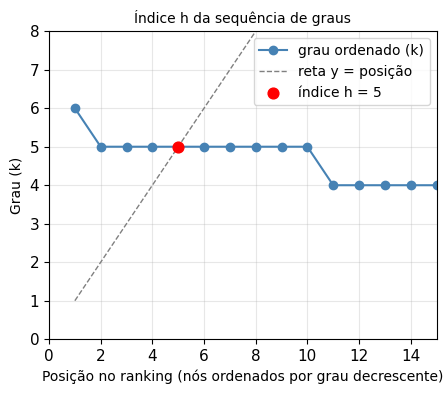

In [21]:
# Visualização do índice h (análoga ao gráfico clássico de h-index)
graus_ordenados = np.sort(graus)[::-1]
posicoes = np.arange(1, len(graus_ordenados) + 1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(posicoes, graus_ordenados,'-o', color="steelblue", linewidth=1.5, label="grau ordenado (k)")
ax.plot(posicoes, posicoes, color="gray", linestyle="--", linewidth=1, label="reta y = posição")
ax.scatter([h], [h], color="red", zorder=5, s=60, label=f"índice h = {h}")
ax.set_xlim(0, min(3*h, N))
ax.set_ylim(0, graus_ordenados[:min(3*h, N)].max() + 2)
ax.set_xlabel("Posição no ranking (nós ordenados por grau decrescente)", fontsize = 10)
ax.set_ylabel("Grau (k)", fontsize = 10)
ax.set_title("Índice h da sequência de graus", fontsize = 10)
ax.legend(fontsize = 10)
plt.show()

### 14. Coeficiente de Gini dos graus

Emprestado da economia (onde mede desigualdade de renda), o **coeficiente de Gini** aplicado aos graus quantifica o quão desigualmente a conectividade está distribuída entre os nós:

$$G = \frac{\sum_{i=1}^N \sum_{j=1}^N |k_i - k_j|}{2N^2 \langle k \rangle}$$

- $G = 0$: todos os nós têm exatamente o mesmo grau (igualdade perfeita).
- $G \to 1$: a conectividade está extremamente concentrada em poucos nós (forte desigualdade).

Uma forma equivalente e mais eficiente de calcular usa a **curva de Lorenz** dos graus ordenados.


In [22]:
def coeficiente_gini(sequencia):
    x = np.sort(np.array(sequencia, dtype=float))
    n = len(x)
    soma_cumulativa = np.cumsum(x)
    return (n + 1 - 2 * np.sum(soma_cumulativa) / soma_cumulativa[-1]) / n

gini_k = coeficiente_gini(graus)
print(f"Coeficiente de Gini dos graus: {gini_k:.4f}")

Coeficiente de Gini dos graus: 0.1280


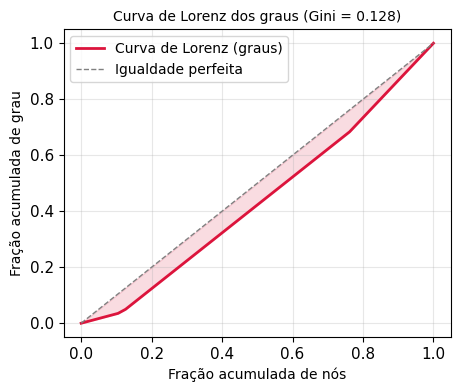

In [23]:
# Curva de Lorenz dos graus
graus_ordenados_asc = np.sort(graus)
soma_cum = np.cumsum(graus_ordenados_asc)
lorenz = np.insert(soma_cum / soma_cum[-1], 0, 0)
eixo_populacao = np.linspace(0, 1, len(lorenz))

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(eixo_populacao, lorenz, color="crimson", linewidth=2, label="Curva de Lorenz (graus)")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Igualdade perfeita")
ax.fill_between(eixo_populacao, lorenz, eixo_populacao, color="crimson", alpha=0.15)
ax.set_xlabel("Fração acumulada de nós", fontsize = 10)
ax.set_ylabel("Fração acumulada de grau", fontsize = 10)
ax.set_title(f"Curva de Lorenz dos graus (Gini = {gini_k:.3f})", fontsize = 10)
ax.legend(fontsize = 10)
plt.show()

### 15. Tabela-resumo das medidas de grau

Consolidamos abaixo todas as medidas calculadas ao longo do notebook em uma única tabela, útil para relatórios ou para comparar diferentes redes/cidades.


In [24]:
resumo = pd.DataFrame({
    "Medida": [
        "Número de nós (N)", "Número de arestas (E)",
        "Grau médio <k>", "Segundo momento <k^2>", "Terceiro momento <k^3>",
        "Variância do grau", "Desvio padrão do grau", "Coeficiente de variação",
        "Entropia do grau (bits)", "Entropia normalizada",
        "Grau mínimo", "Grau máximo",
        "Q1", "Mediana (Q2)", "Q3", "IQR",
        "Grau médio dos vizinhos <knn>", "Assortatividade de grau",
        "Índice h", "Coeficiente de Gini",
    ],
    "Valor": [
        N, E,
        grau_medio, m2, m3,
        var_k, std_k, cv_k,
        H, H_norm,
        k_min, k_max,
        q1, q2, q3, iqr,
        knn_medio_geral, assortatividade,
        h, gini_k,
    ]
})
resumo["Valor"] = resumo["Valor"].round(4)
resumo

,Medida,Valor
0,Número de nós (N),9217.0000
1,Número de arestas (E),13881.0000
2,Grau médio <k>,3.0120
3,Segundo momento <k^2>,9.7511
4,Terceiro momento <k^3>,32.8337
5,Variância do grau,0.6787
6,Desvio padrão do grau,0.8238
7,Coeficiente de variação,0.2735
8,Entropia do grau (bits),1.3767
9,Entropia normalizada,0.5326


### Discussão

Redes viárias urbanas tendem a apresentar um comportamento bem particular quando comparadas a outras redes complexas (redes sociais, biológicas, tecnológicas):

- A distribuição de grau costuma ser **estreita e concentrada** em torno de 3–4, refletindo restrições físicas e de planejamento urbano — não há espaço para "hubs" com centenas de ruas convergindo no mesmo ponto.
- Como consequência, o **coeficiente de variação** e o **coeficiente de Gini** costumam ser bem mais baixos do que em redes livres de escala, e a **entropia normalizada** tende a ser moderada (pois há poucos valores de grau possíveis).
- O **índice h**, por outro lado, ainda é informativo para comparar sub-regiões de uma mesma cidade, ou cidades com tamanhos de rede diferentes, funcionando como uma medida robusta e concisa.

Essas conclusões podem (e devem) ser comparadas com outras cidades, ou com redes de outros domínios, para se ter uma noção mais ampla de como a distribuição de grau se comporta em diferentes contextos.


## 16. Exercícios

1. **Outra cidade**: repita toda a análise para uma cidade diferente (por exemplo, sua cidade natal) e compare a tabela-resumo com a obtida aqui para São Carlos. O que muda? O que permanece parecido?

2. **Tipo de rede**: refaça o download usando `network_type="walk"` (rede para pedestres) ou `network_type="bike"` em vez de `"drive"`. As medidas de grau mudam significativamente? Por quê?

3. **Bairro vs. cidade**: use `ox.graph_from_address()` ou `ox.graph_from_point()` com um raio pequeno (ex: 1 km) para extrair a rede de um bairro específico e compare suas medidas de grau com as da cidade inteira.

4. **Redes aleatórias de comparação**: gere um grafo aleatório de Erdős–Rényi (`nx.gnm_random_graph`) e um grafo livre de escala (`nx.barabasi_albert_graph`) com o mesmo número de nós e arestas (aproximadamente) da rede viária. Compare a entropia, o coeficiente de variação e o coeficiente de Gini dos três grafos. Qual medida mais evidencia a diferença entre eles?

5. **Correlação entre medidas**: calcule a correlação entre `knn` e grau para cada nó individualmente (não agregado por classe de grau) e visualize um scatter plot. Isso reforça ou contradiz o coeficiente de assortatividade calculado na Seção 12?

6. **Robustez do índice h**: remova aleatoriamente 10% dos nós da rede e recalcule o índice h e o grau máximo. Repita esse processo várias vezes (simulação de Monte Carlo) e compare a variabilidade das duas medidas. Qual delas é mais estável?


## Referências

- Newman, M. E. J. (2010). *Networks: An Introduction*. Oxford University Press.
- Boeing, G. (2017). OSMnx: New methods for acquiring, constructing, analyzing, and visualizing complex street networks. *Computers, Environment and Urban Systems*.
- Hirsch, J. E. (2005). An index to quantify an individual's scientific research output. *PNAS*.
- Gini Index - Sparsity Measure of a Network Graph, https://arxiv.org/pdf/1612.07074